In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os,sys
#sys.path.append('/work/qdiff/mo_utils')
sys.executable

'/home/nadavg/anaconda3/envs/qdiff/bin/python'

In [3]:
print(os.getcwdb())
os.chdir('/home/nadavg/q-diffusion')
print(os.getcwdb())

b'/home/nadavg/q-diffusion/scripts/hf15'
b'/home/nadavg/q-diffusion'


In [4]:
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from src.utils.torch_utils import add_full_name_to_module
from mo_utils.utils.stand_alone_utils.quant_utils import calc_snr

from scripts.hf15.init_pipe import init_pipe

libtmux not installed ??


In [24]:
pipe = init_pipe()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [25]:
_=pipe.to('cuda')

In [26]:
unet = pipe.unet
add_full_name_to_module(unet)

In [27]:
type(unet.time_embedding.post_act)

NoneType

In [ ]:
unet.up_blocks[0].resnets[1]

In [28]:
generator = torch.Generator("cuda").manual_seed(42)  # 
Iorg = pipe('a puppy wearing a hat',num_inference_steps=20,generator= generator).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
plt.imshow(Iorg)

In [7]:
from qdiff.quant_model import QuantModel

In [8]:
wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'mse',
                'symmetric':True,'debug':True}

aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'mse', 
            'leaf_param':  True, 'debug':True,'split_to_16bits':False,
            'act_quant_mode' :'rtn'}


In [16]:
pipe = init_pipe()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [17]:
unet = pipe.unet
add_full_name_to_module(unet)

In [18]:
unet.time_embedding

TimestepEmbedding(
  (linear_1): Linear(in_features=320, out_features=1280, bias=True)
  (act): SiLU()
  (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
)

In [19]:
qnn = QuantModel(
                model=unet, weight_quant_params=wq_params, act_quant_params=aq_params,
                act_quant_mode="qdiff", sm_abit=16,quant_act_ops = True, 
                split=True,use_post_act_temb=True)
          

/home/nadavg/q-diffusion/qdiff/quant_model.py:24: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  self.in_channels = model.in_channels


In [13]:
qnn.model.down_blocks[0].attentions[0].transformer_blocks[0].attn1.act_quantizer_w

UniformAffineQuantizer(bit=16, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)

In [20]:
qnn.model.time_embedding#.use_post_act 
#qnn.model.down_blocks[0].resnets[0]

TimeStepEmbeddingSilu(
  (linear_1): QuantModule(
    in_features=320, out_features=1280, bias=True
    (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=True, channel_wise=True, leaf_param=False)
    (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)
    (activation_function): StraightThrough()
  )
  (act): SiLU()
  (linear_2): QuantModule(
    in_features=1280, out_features=1280, bias=True
    (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=True, channel_wise=True, leaf_param=False)
    (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)
    (activation_function): StraightThrough()
  )
)

In [21]:
add_full_name_to_module(qnn)

In [22]:
qnn.set_quant_state(weight_quant=False, act_quant=False)

In [19]:
qnn.model.down_blocks[0].resnets[0].ew_add_1.kernel_1.dtype

torch.float32

In [23]:
pipe.unet = qnn.model

In [24]:
_=pipe.to('cuda')

In [25]:
generator = torch.Generator("cuda").manual_seed(42)  # 
Iq = pipe('a puppy wearing a hat',num_inference_steps=20,generator= generator).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

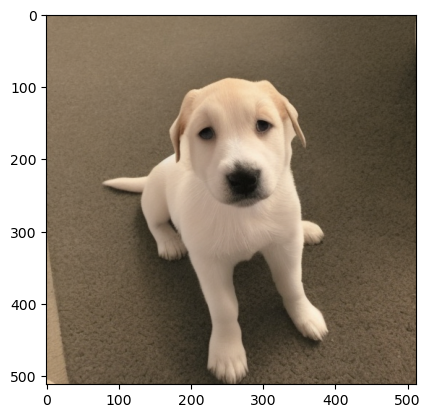

In [26]:
plt.imshow(Iq)

In [29]:
#pil to numpy
Iorg = np.array(Iorg)
Iq = np.array(Iq)
calc_snr(Iorg,Iq)

35.20998623453315

In [ ]:
#qnn.model.down_blocks[0].resnets[1].ew_add_1.kernel_1.shape
#qnn.model.down_blocks[0].attentions[0].transformer_blocks[0].ew_add_1.kernel_2.shape